In [2]:
# Load data
import pandas as pd
import numpy as np
import os

def load(name, **kw):
    path = os.path.join(DATA_DIR, name)
    df = pd.read_csv(path, **kw)
    print(f"  Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    return df
def save(df, name):
    path = os.path.join(OUT_DIR, name)
    df.to_csv(path, index=False)
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f"  Saved {name}: {df.shape[0]:,} rows ({size_mb:.1f} MB)")

DATA_DIR = r"C:\\Users\\nguye\\Desktop\\datathon\\data"
OUT_DIR  = r"C:\\Users\\nguye\\Desktop\\datathon\\tableau_data"

orders      = load('orders.csv',      parse_dates=['order_date'])
order_items = load('order_items.csv')
payments    = load('payments.csv')
products    = load('products.csv')
customers   = load('customers.csv',   parse_dates=['signup_date'])
geography   = load('geography.csv')
promotions  = load('promotions.csv',  parse_dates=['start_date', 'end_date'])
shipments   = load('shipments.csv',   parse_dates=['ship_date', 'delivery_date'])
returns     = load('returns.csv',     parse_dates=['return_date'])
reviews     = load('reviews.csv',     parse_dates=['review_date'])
inventory   = load('inventory.csv',   parse_dates=['snapshot_date'])
web_traffic = load('web_traffic.csv', parse_dates=['date'])
sales       = load('sales.csv',       parse_dates=['Date'])

DATA_DIR = r"C:\\Users\\nguye\\Desktop\\datathon\\tableau_data"

agg_monthly_summary = load('agg_monthly_summary.csv')



  Loaded orders.csv: 646,945 rows x 8 cols


C:\Users\nguye\AppData\Local\Temp\ipykernel_25916\3635718512.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, **kw)


  Loaded order_items.csv: 714,669 rows x 7 cols
  Loaded payments.csv: 646,945 rows x 4 cols
  Loaded products.csv: 2,412 rows x 8 cols
  Loaded customers.csv: 121,930 rows x 7 cols
  Loaded geography.csv: 39,948 rows x 4 cols
  Loaded promotions.csv: 50 rows x 10 cols
  Loaded shipments.csv: 566,067 rows x 4 cols
  Loaded returns.csv: 39,939 rows x 7 cols
  Loaded reviews.csv: 113,551 rows x 7 cols
  Loaded inventory.csv: 60,247 rows x 17 cols
  Loaded web_traffic.csv: 3,652 rows x 7 cols
  Loaded sales.csv: 3,833 rows x 3 cols
  Loaded agg_monthly_summary.csv: 126 rows x 8 cols


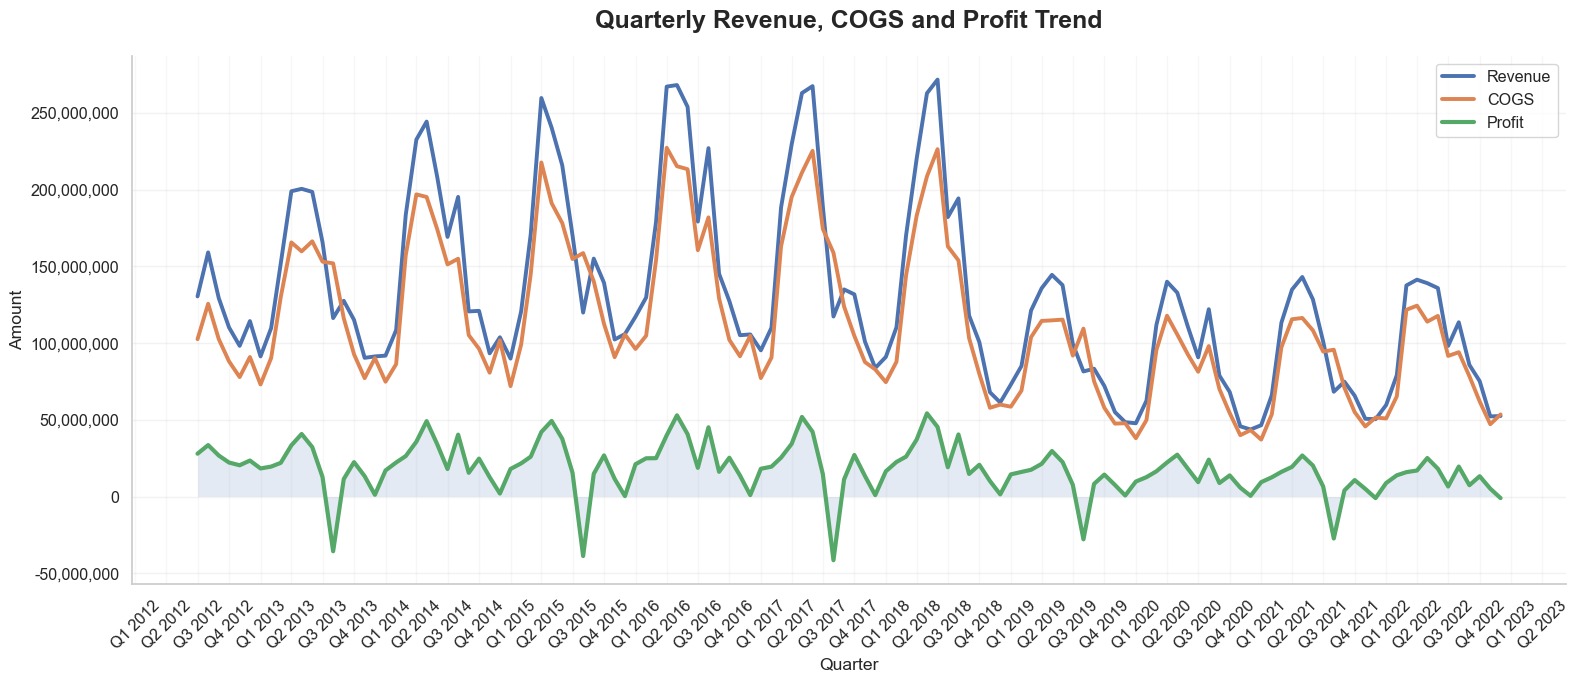

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid", font_scale=1.05)

sales = pd.read_csv("data/sales.csv", parse_dates=["Date"])

sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.to_period("M")
sales["profit"] = sales["Revenue"] - sales["COGS"]

# Gom dữ liệu theo tháng
monthly_sales = (
    sales
    .groupby("month", as_index=False)[["Revenue", "COGS", "profit"]]
    .sum()
)

monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()

plt.figure(figsize=(16, 7))

plt.plot(monthly_sales["month"], monthly_sales["Revenue"], linewidth=2.8, label="Revenue")
plt.plot(monthly_sales["month"], monthly_sales["COGS"], linewidth=2.8, label="COGS")
plt.plot(monthly_sales["month"], monthly_sales["profit"], linewidth=3, label="Profit")

plt.fill_between(
    monthly_sales["month"],
    monthly_sales["profit"],
    alpha=0.15
)

ax = plt.gca()

# 👉 TRỤC X THEO QUÝ
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # mỗi 3 tháng = 1 quý

# Format thành Q1 2023
def format_quarter(x, pos):
    date = mdates.num2date(x)
    quarter = (date.month - 1) // 3 + 1
    return f"Q{quarter} {date.year}"

ax.xaxis.set_major_formatter(format_quarter)

# Optional: grid nhẹ theo năm
ax.xaxis.set_minor_locator(mdates.YearLocator())

plt.title("Quarterly Revenue, COGS and Profit Trend", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Quarter")
plt.ylabel("Amount")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.grid(axis="x", which="major", alpha=0.15)

plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_24064\3060292205.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = sales.resample('M', on='Date').agg(


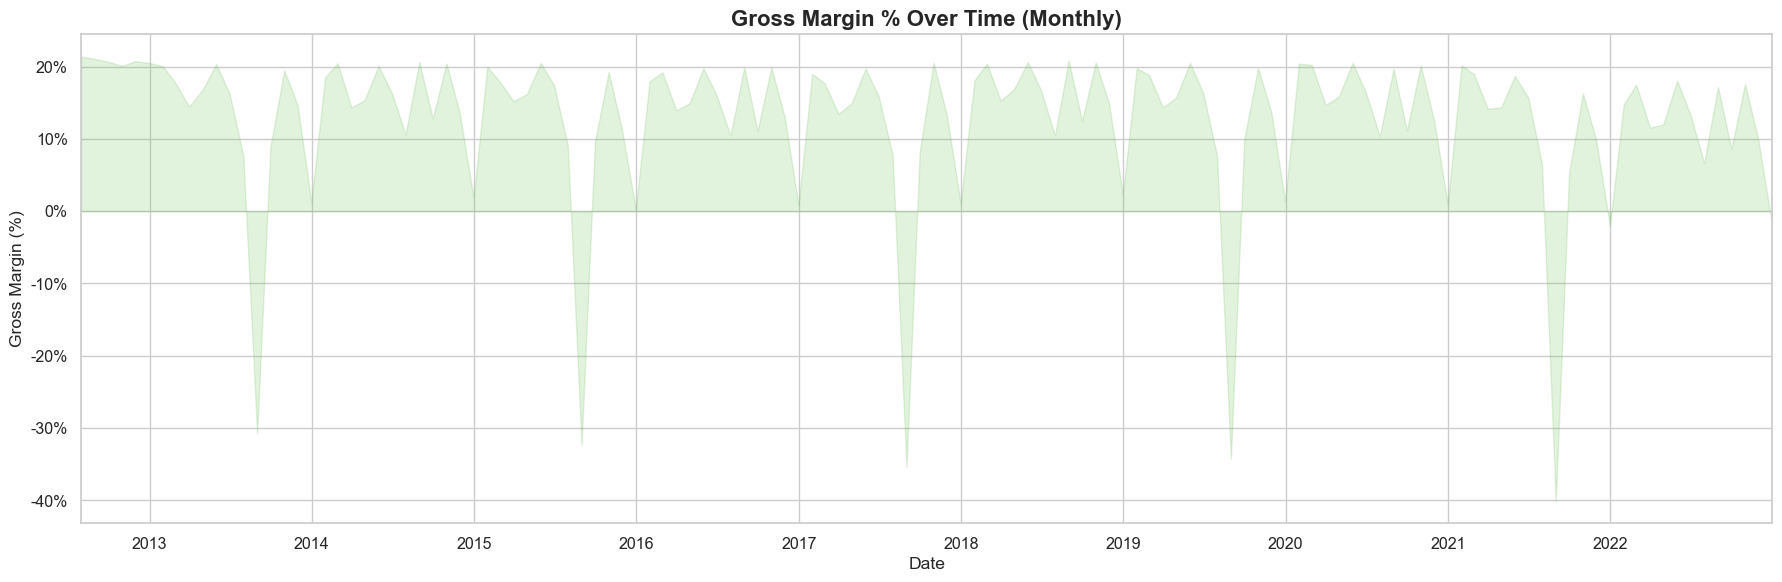

In [15]:
# ===== Gross Margin % MONTHLY (tight x-axis, no padding) =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data
sales = pd.read_csv('data/sales.csv')

# Parse date
sales['Date'] = pd.to_datetime(sales['Date'])

# --------------------------------------------------
# 1. Aggregate theo tháng
# --------------------------------------------------
monthly = sales.resample('M', on='Date').agg(
    total_revenue=('Revenue', 'sum'),
    total_cogs=('COGS', 'sum')
).reset_index()

# --------------------------------------------------
# 2. Compute Gross Margin %
# --------------------------------------------------
monthly['gross_margin_pct'] = (monthly['total_revenue'] - monthly['total_cogs']) / monthly['total_revenue']

# --------------------------------------------------
# 3. Plot
# --------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(18,6))

# Area
ax.fill_between(
    monthly['Date'],
    monthly['gross_margin_pct'],
    color='#6BBF59',
    alpha=0.2
)

# --------------------------------------------------
# 4. Fix trục X (QUAN TRỌNG)
# --------------------------------------------------
ax.set_xlim(monthly['Date'].min(), monthly['Date'].max())  # bỏ padding
ax.margins(x=0)  # loại bỏ margin mặc định

# format tick theo tháng/năm
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --------------------------------------------------
# 5. Format
# --------------------------------------------------
ax.set_title("Gross Margin % Over Time (Monthly)", fontsize=16, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Gross Margin (%)")

# format % trục Y
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()
plt.show()

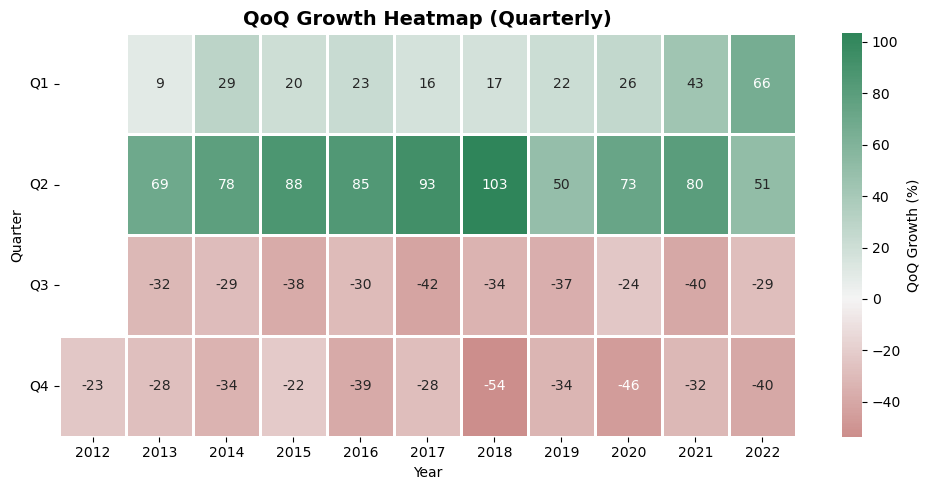

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Copy data
df = agg_monthly_summary.copy()

df['year'] = df['year_month'].str[:4]
df['month_num'] = df['year_month'].str[5:7].astype(int)

df['quarter'] = ((df['month_num'] - 1) // 3) + 1
df['quarter_label'] = 'Q' + df['quarter'].astype(str)

df['revenue'] = df['revenue']

quarter_df = df.groupby(['year', 'quarter', 'quarter_label']).agg(
    revenue=('revenue', 'sum')
).reset_index()

quarter_df = quarter_df.sort_values(['year', 'quarter'])

quarter_df['qoq_growth_pct'] = quarter_df['revenue'].pct_change() * 100

heatmap_data = quarter_df.pivot(
    index='quarter_label',
    columns='year',
    values='qoq_growth_pct'
)

heatmap_data = heatmap_data.reindex(['Q1','Q2','Q3','Q4'])
cmap = LinearSegmentedColormap.from_list(
    "custom_red_white_green",
    ["#A8312C", "#F4F4F4", "#2F855A"]
)

plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    cmap=cmap,
    center=0,
    annot=True,
    fmt=".0f",
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'QoQ Growth (%)'}
)

plt.title("QoQ Growth Heatmap (Quarterly)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Quarter")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

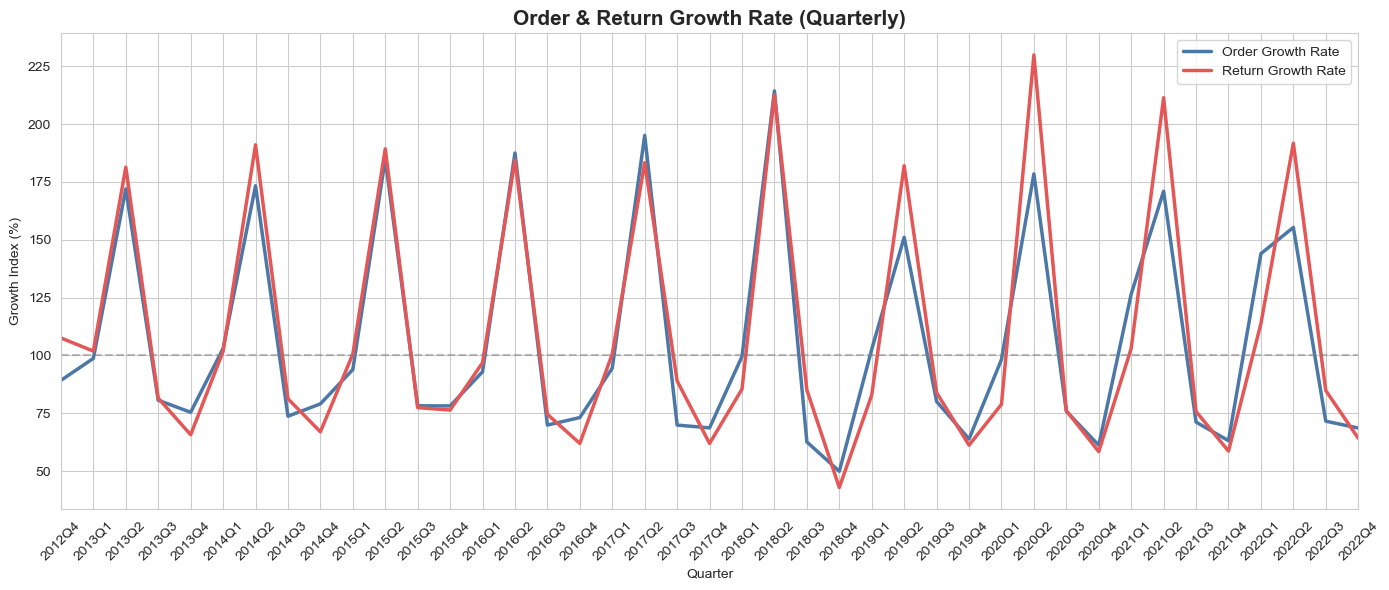

In [12]:
# ===== Order & Return Growth Rate (Quarterly) =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('data/orders.csv')
returns = pd.read_csv('data/returns.csv')

# --------------------------------------------------
# 1. Parse date
# --------------------------------------------------
orders['order_date'] = pd.to_datetime(orders['order_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])

# --------------------------------------------------
# 2. Create quarter
# --------------------------------------------------
orders['quarter'] = orders['order_date'].dt.to_period('Q')
returns['quarter'] = returns['return_date'].dt.to_period('Q')

# --------------------------------------------------
# 3. Aggregate
# --------------------------------------------------
orders_q = orders.groupby('quarter').agg(
    total_orders=('order_id', 'nunique')
).reset_index()

returns_q = returns.groupby('quarter').agg(
    total_returns=('order_id', 'nunique')
).reset_index()

# --------------------------------------------------
# 4. Merge
# --------------------------------------------------
df = orders_q.merge(returns_q, on='quarter', how='left')
df['total_returns'] = df['total_returns'].fillna(0)

# sort
df = df.sort_values('quarter')

# --------------------------------------------------
# 5. Compute growth rate (INDEX style)
# --------------------------------------------------
df['order_growth_rate'] = df['total_orders'] / df['total_orders'].shift(1) * 100
df['return_growth_rate'] = df['total_returns'] / df['total_returns'].shift(1) * 100

# drop first row (no previous quarter)
df = df.dropna()

# convert quarter to string for plotting
df['quarter'] = df['quarter'].astype(str)

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------
# ===== Clean Quarterly Growth Chart (no padding) =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(14,6))

# Plot
ax.plot(
    df['quarter'],
    df['order_growth_rate'],
    label='Order Growth Rate',
    color='#4C78A8',
    linewidth=2.5
)

ax.plot(
    df['quarter'],
    df['return_growth_rate'],
    label='Return Growth Rate',
    color='#E45756',
    linewidth=2.5
)

# baseline
ax.axhline(100, linestyle='--', color='gray', alpha=0.5)

# --------------------------------------------------
# FIX padding trục X
# --------------------------------------------------
ax.margins(x=0)
ax.set_xlim(0, len(df['quarter']) - 1)

# --------------------------------------------------
# Format
# --------------------------------------------------
ax.set_xticks(range(len(df['quarter'])))
ax.set_xticklabels(df['quarter'], rotation=45)

ax.set_title("Order & Return Growth Rate (Quarterly)", fontsize=15, fontweight='bold')
ax.set_xlabel("Quarter")
ax.set_ylabel("Growth Index (%)")

ax.legend()

plt.tight_layout()
plt.show()

In [6]:
# ===== Market Basket Analysis: All Segments Summary Only =====

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

order_items = pd.read_csv("data/order_items.csv")
products = pd.read_csv("data/products.csv")

df = order_items.merge(
    products[["product_id", "product_name", "segment"]],
    on="product_id",
    how="left"
)

top_n_products = 300
min_support = 0.001
min_confidence = 0.2
max_len = 4
top_n_display = 30

all_combos = []
all_rules = []

segments = sorted(df["segment"].dropna().unique())

for segment_focus in segments:
    df_seg = df[df["segment"] == segment_focus].copy()

    top_products = (
        df_seg.groupby("product_id")["order_id"]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n_products)
        .index
    )

    df_seg = df_seg[df_seg["product_id"].isin(top_products)].copy()

    basket = (
        df_seg.groupby(["order_id", "product_name"])["quantity"]
        .sum()
        .unstack(fill_value=0)
    )

    basket = (basket > 0).astype(bool)
    basket = basket[basket.sum(axis=1) >= 2]

    if basket.shape[0] < 10 or basket.shape[1] < 2:
        continue

    frequent_itemsets = apriori(
        basket,
        min_support=min_support,
        use_colnames=True,
        max_len=max_len
    )

    if frequent_itemsets.empty:
        continue

    frequent_itemsets["combo_size"] = frequent_itemsets["itemsets"].apply(len)

    combos = frequent_itemsets[frequent_itemsets["combo_size"] >= 2].copy()

    if not combos.empty:
        combos["segment"] = segment_focus
        combos["combo"] = combos["itemsets"].apply(
            lambda x: " + ".join(sorted(list(x)))
        )

        all_combos.append(
            combos[["segment", "combo", "combo_size", "support"]]
        )

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    if not rules.empty:
        rules["segment"] = segment_focus
        rules["antecedents_str"] = rules["antecedents"].apply(
            lambda x: " + ".join(sorted(list(x)))
        )
        rules["consequents_str"] = rules["consequents"].apply(
            lambda x: " + ".join(sorted(list(x)))
        )
        rules["rule"] = rules["antecedents_str"] + " → " + rules["consequents_str"]

        all_rules.append(
            rules[["segment", "rule", "support", "confidence", "lift"]]
        )

combos_all = pd.concat(all_combos, ignore_index=True) if all_combos else pd.DataFrame()
rules_all = pd.concat(all_rules, ignore_index=True) if all_rules else pd.DataFrame()

top_combos_all_segments = (
    combos_all
    .sort_values(["support", "combo_size"], ascending=[False, False])
    .head(top_n_display)
)

top_rules_all_segments = (
    rules_all
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .head(top_n_display)
)

display(top_combos_all_segments)
display(top_rules_all_segments)

top_combos_all_segments.to_csv("top_product_combos_all_segments.csv", index=False)
top_rules_all_segments.to_csv("top_association_rules_all_segments.csv", index=False)

C:\Users\nguye\AppData\Local\Temp\ipykernel_25916\2383913895.py:6: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("data/order_items.csv")


,segment,combo,combo_size,support
765,Standard,UrbanVN UR-02 + UrbanVN UR-31,2,0.166667
748,Premium,VietMotion RS-02 + VietMotion RS-08,2,0.126437
840,Trendy,VietMotion YY-05 + VietMotion YY-09,2,0.090000
20,Activewear,HanoiStreet RP-79 + HanoiStreet RP-80,2,0.088132
756,Standard,DragonWear UR-34 + HanoiStreet UR-08,2,0.083333
757,Standard,DragonWear UR-41 + MekongFit UR-10,2,0.083333
758,Standard,HanoiStreet UR-08 + UrbanVN UR-39,2,0.083333
759,Standard,LotusWear UR-01 + UrbanVN UR-18,2,0.083333
760,Standard,LotusWear UR-10 + LotusWear UR-20,2,0.083333
761,Standard,LotusWear UR-33 + UrbanVN UR-07,2,0.083333


,segment,rule,support,confidence,lift
79,Activewear,MekongFit RP-57 → MekongFit RP-58,0.001059,1.000000,928.984127
78,Activewear,MekongFit RP-58 → MekongFit RP-57,0.001059,0.984127,928.984127
11,Activewear,HanoiStreet RP-28 → HanoiStreet RP-27,0.001042,0.983871,899.719254
10,Activewear,HanoiStreet RP-27 → HanoiStreet RP-28,0.001042,0.953125,899.719254
89,Activewear,UrbanVN RP-16 → UrbanVN RP-15,0.001094,0.955224,860.083582
88,Activewear,UrbanVN RP-15 → UrbanVN RP-16,0.001094,0.984615,860.083582
55,Activewear,MekongFit RP-13 → MekongFit RP-14,0.001264,1.000000,780.346667
54,Activewear,MekongFit RP-14 → MekongFit RP-13,0.001264,0.986667,780.346667
106,Activewear,VietMode MP-20 → VietMode MP-19,0.001367,1.000000,722.543210
107,Activewear,VietMode MP-19 → VietMode MP-20,0.001367,0.987654,722.543210


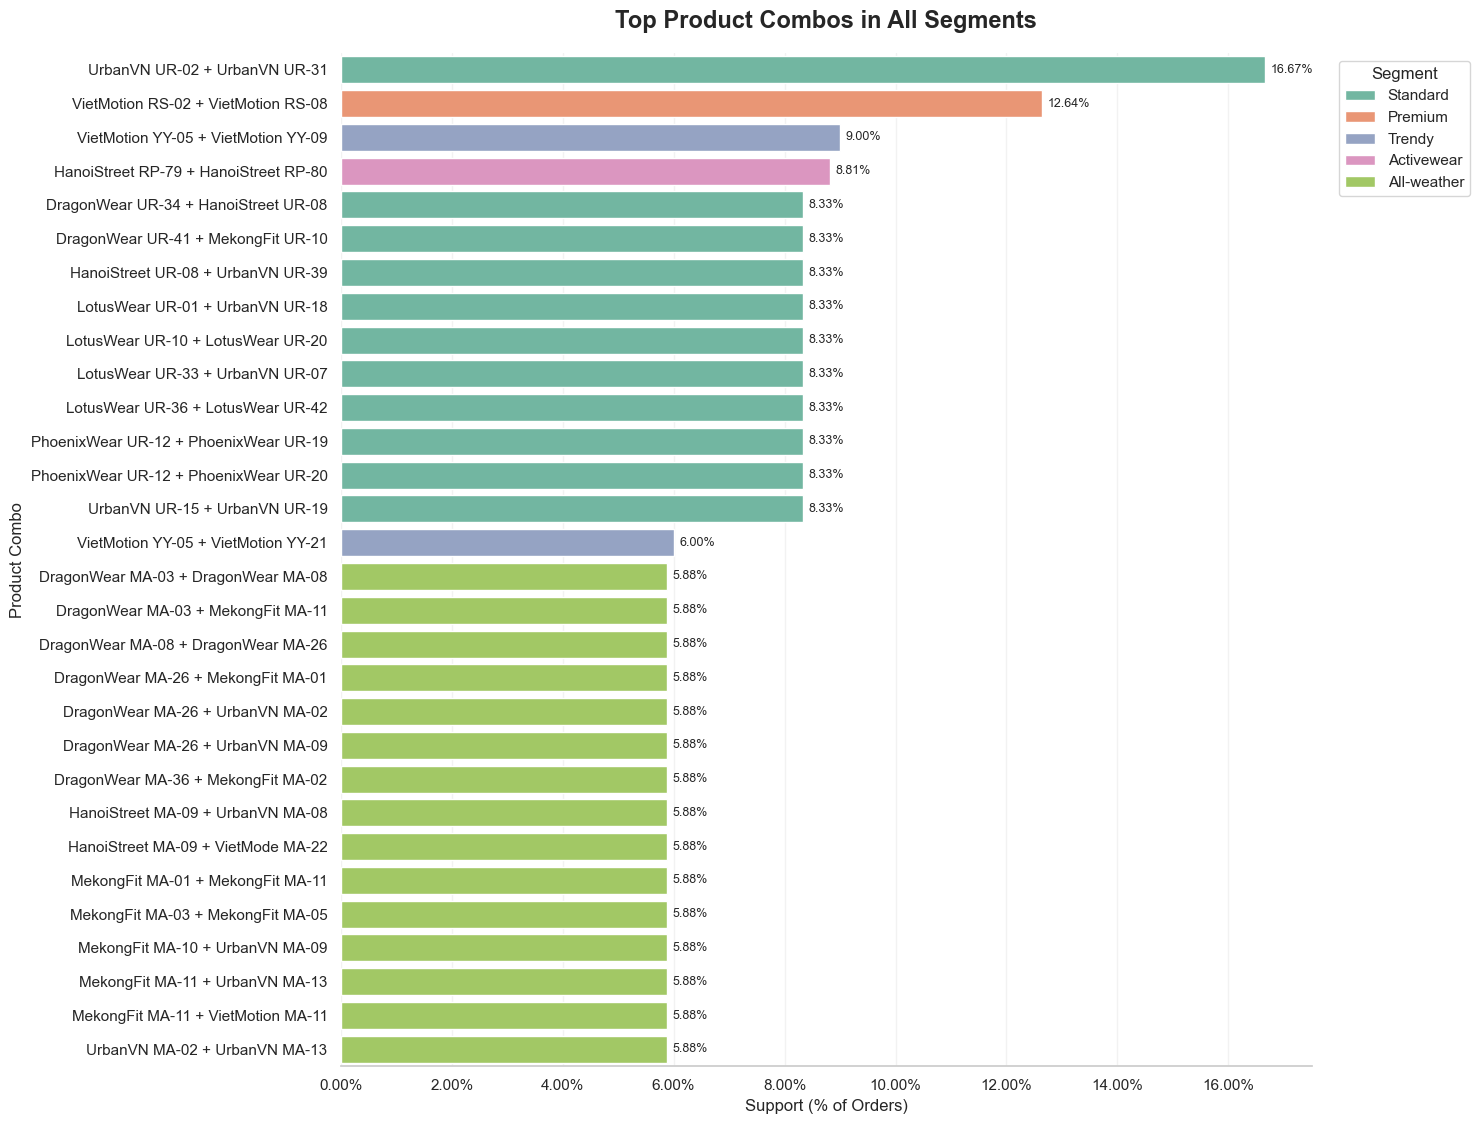

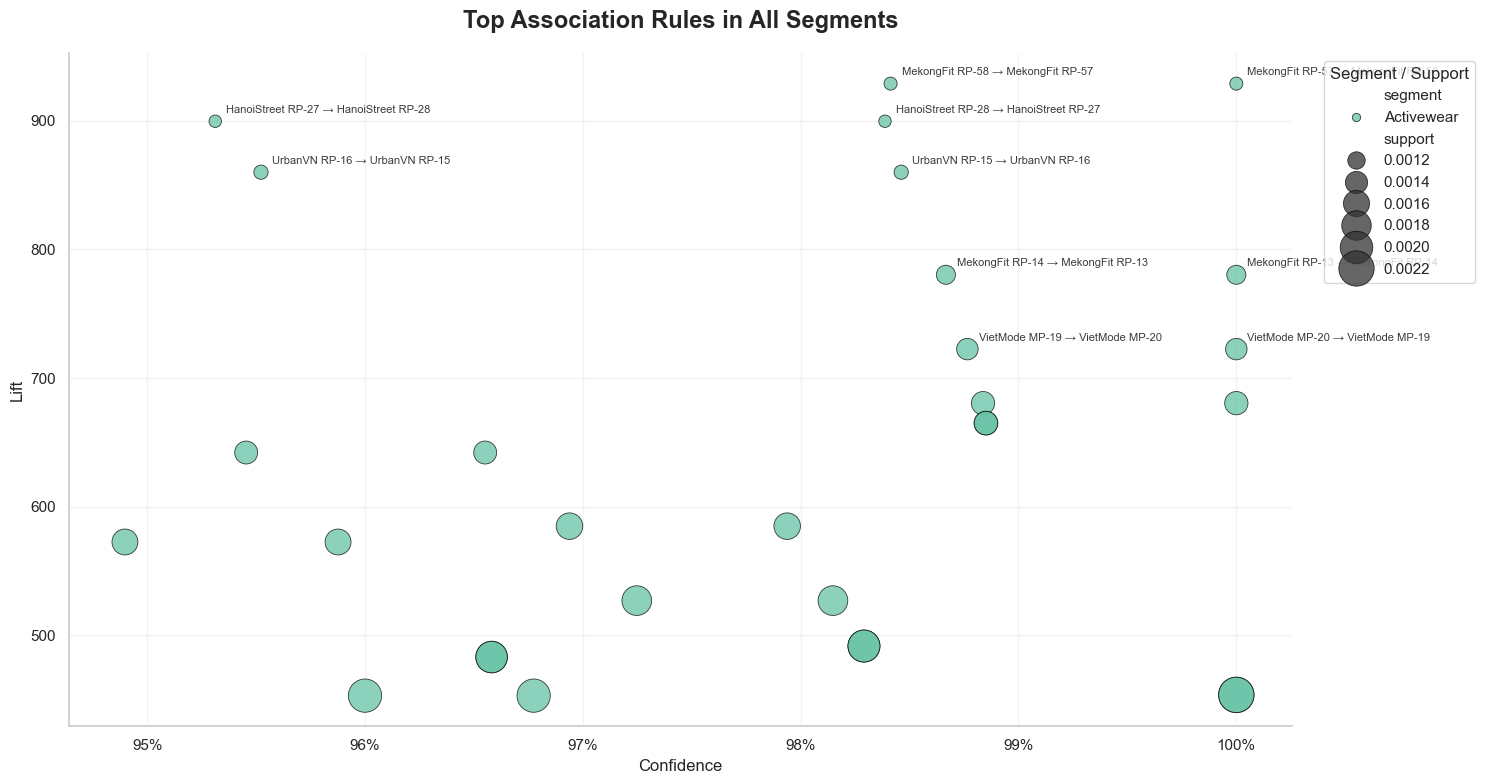

In [11]:
# ===== Visualization: Top Combos + Top Association Rules =====

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import textwrap

sns.set_theme(style="whitegrid", font_scale=1.0)

# --------------------------------------------------
# 1. Top Product Combos in All Segments
# --------------------------------------------------
plot_combos = top_combos_all_segments.copy()

plot_combos["combo_short"] = plot_combos["combo"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=45))
)

plot_combos = plot_combos.sort_values("support", ascending=False)

plt.figure(figsize=(15, max(8, len(plot_combos) * 0.38)))

ax = sns.barplot(
    data=plot_combos,
    x="support",
    y="combo_short",
    hue="segment",
    dodge=False,
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_width():.2%}" for v in container],
        padding=4,
        fontsize=9
    )

ax.set_title(
    "Top Product Combos in All Segments",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Support (% of Orders)", fontsize=12)
ax.set_ylabel("Product Combo", fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.legend(
    title="Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. Top Association Rules in All Segments
# --------------------------------------------------
plot_rules = top_rules_all_segments.copy()

# Rút gọn rule để nhìn sạch hơn
plot_rules["rule_short"] = plot_rules["rule"].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=38))
)

# Chỉ label top 10 rule theo lift để tránh rối
label_df = plot_rules.nlargest(10, "lift")

plt.figure(figsize=(15, 8))

ax = sns.scatterplot(
    data=plot_rules,
    x="confidence",
    y="lift",
    hue="segment",
    size="support",
    sizes=(80, 650),
    alpha=0.75,
    edgecolor="black",
    linewidth=0.6,
    palette="Set2"
)

for _, row in label_df.iterrows():
    ax.annotate(
        row["rule_short"],
        xy=(row["confidence"], row["lift"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=8,
        alpha=0.9
    )

ax.set_title(
    "Top Association Rules in All Segments",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Confidence", fontsize=12)
ax.set_ylabel("Lift", fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

ax.grid(alpha=0.22)

ax.legend(
    title="Segment / Support",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()